<a href="https://colab.research.google.com/github/diegopenia/Colorimetria/blob/main/INSTUMENTO_FINAL_COLOR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

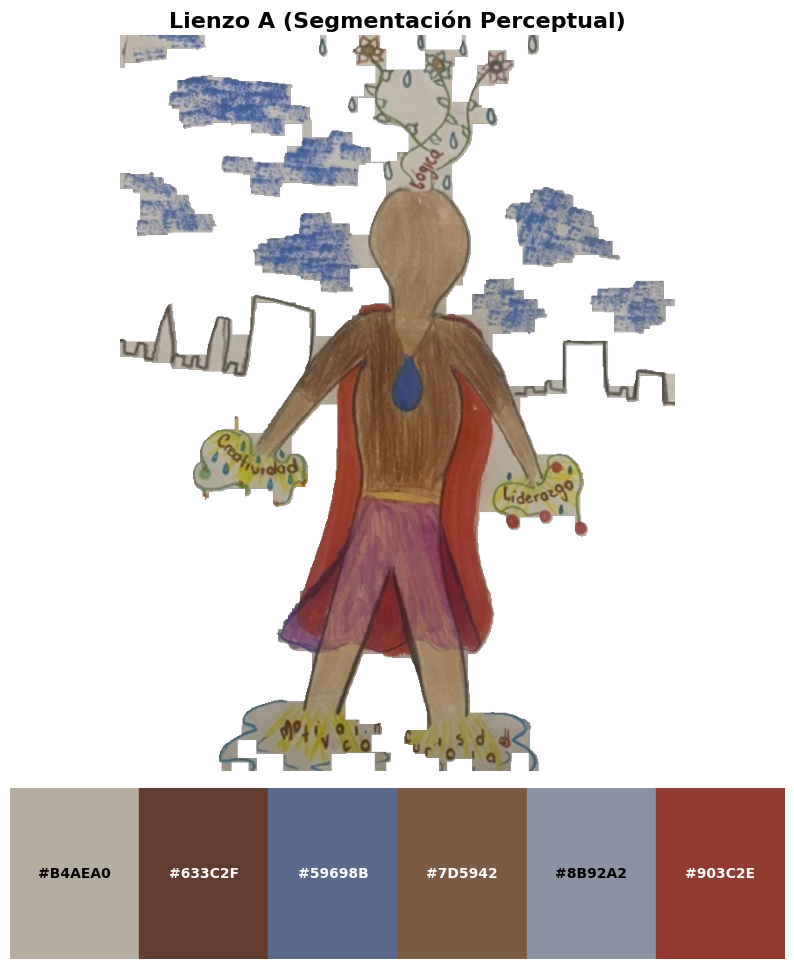

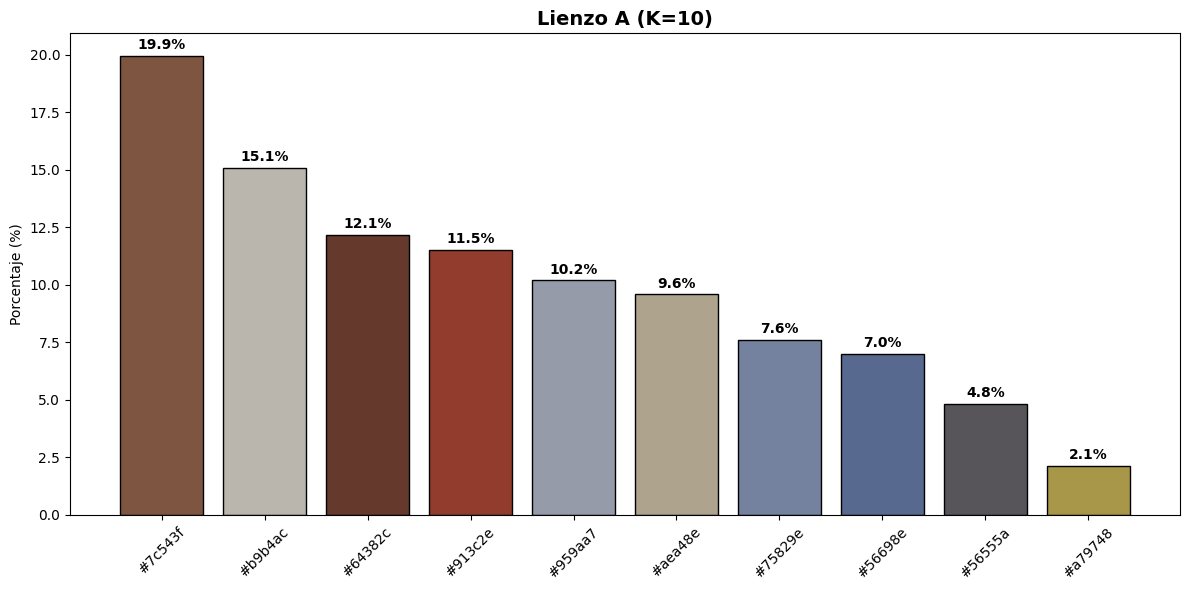


           REPORTE DE AUDITORÍA PERCEPTUAL


,Etapa,Métrica,Valor,Timestamp
0,Carga,Resolución,638x847 px,14:08:10
1,Segmentación,Píxeles Útiles,205337,14:08:11
2,Análisis Paleta 6,Inercia,79765531,14:08:13
3,Análisis Barras 10,Inercia,44582881,14:08:18


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import ndimage
from sklearn.cluster import KMeans
from collections import Counter
import time
from skimage import color

# --- 1. CONFIGURACIÓN Y REPOSITORIO DE AUDITORÍA ---
class Config:
    PATH_INPUT = "/content/Heroina 1.png"
    IGNORE_HEX = "#8E7D69"
    COLOR_TOLERANCE = 45
    # Mantenemos el parámetro por si deseas usarlo en otros experimentos,
    # pero para el Resultado 1 y 2 usaremos 0 para forzar K exacto.
    DELTA_E_THRESHOLD = 15.0
    N_CLUSTERS_PALETTE = 6
    N_CLUSTERS_BARS = 10
    RANDOM_SEED = 42
    audit_data = []

def record_audit(step, metric, value):
    Config.audit_data.append({
        "Etapa": step,
        "Métrica": metric,
        "Valor": value,
        "Timestamp": time.strftime("%H:%M:%S")
    })

# --- 2. NÚCLEO DE PROCESAMIENTO ---

def get_base_data(config):
    img_bgr = cv2.imread(config.PATH_INPUT)
    if img_bgr is None: raise FileNotFoundError(f"No se encontró la imagen")

    h, w, _ = img_bgr.shape
    record_audit("Carga", "Resolución", f"{w}x{h} px")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Segmentación por bordes
    edges = cv2.Canny(gray, 100, 200)
    mask = ndimage.binary_fill_holes(cv2.morphologyEx(edges, cv2.MORPH_CLOSE, np.ones((20,20), np.uint8)))

    rgba = np.zeros((h, w, 4), dtype=np.uint8)
    rgba[mask, :3], rgba[mask, 3] = img_rgb[mask], 255

    pixels_rgb = rgba[mask][:, :3]
    ignore_rgb = np.array([int(config.IGNORE_HEX.lstrip('#')[i:i+2], 16) for i in (0, 2, 4)])
    dist = np.linalg.norm(pixels_rgb - ignore_rgb, axis=1)
    filtered_pixels = pixels_rgb[dist > config.COLOR_TOLERANCE]

    record_audit("Segmentación", "Píxeles Útiles", len(pixels_rgb))
    return rgba, filtered_pixels

def process_clusters_lab(pixels, n_clusters, delta_e_threshold=0, audit_label=None):
    """
    KMeans en RGB. Si delta_e_threshold > 0, fusiona colores similares en LAB.
    Si es 0, devuelve exactamente n_clusters.
    """
    clt = KMeans(n_clusters=n_clusters, n_init=10, random_state=Config.RANDOM_SEED).fit(pixels)
    if audit_label:
        record_audit(f"Análisis {audit_label}", "Inercia", f"{clt.inertia_:.0f}")

    centers_rgb = clt.cluster_centers_
    counts = Counter(clt.labels_)

    if delta_e_threshold == 0:
        # Retorna los K centros ordenados por su índice de cluster
        return centers_rgb, np.array([counts[i] for i in range(n_clusters)])

    # Conversión a LAB para fusión perceptual
    centers_lab = color.rgb2lab(centers_rgb.reshape(-1, 1, 3) / 255.0).reshape(-1, 3)
    merged_cols_rgb, merged_counts = [], []
    skip = set()

    for i in range(len(centers_lab)):
        if i in skip: continue
        curr_rgb, curr_lab, curr_count = centers_rgb[i], centers_lab[i], counts[i]
        for j in range(i + 1, len(centers_lab)):
            if j not in skip:
                dist_de = np.linalg.norm(curr_lab - centers_lab[j])
                if dist_de < delta_e_threshold:
                    curr_rgb = (curr_rgb * curr_count + centers_rgb[j] * counts[j]) / (curr_count + counts[j])
                    curr_count += counts[j]
                    skip.add(j)
        merged_cols_rgb.append(curr_rgb)
        merged_counts.append(curr_count)

    return np.array(merged_cols_rgb), np.array(merged_counts)

# --- 3. FUNCIONES DE RENDERIZADO ---

def render_results(rgba_img, pixels, config):
    # RESULTADO 1: Forzamos exactamente 6 colores
    cols_p, _ = process_clusters_lab(pixels, config.N_CLUSTERS_PALETTE, 0, "Paleta 6")

    fig = plt.figure(figsize=(10, 12))
    grid = plt.GridSpec(5, 1, hspace=0.1)

    ax_img = fig.add_subplot(grid[:4, 0])
    ax_img.imshow(rgba_img)
    ax_img.set_title("Lienzo A (Segmentación Perceptual)", fontsize=16, fontweight='bold')
    ax_img.axis('off')

    ax_pal = fig.add_subplot(grid[4, 0])
    for i, col in enumerate(cols_p):
        ax_pal.add_patch(plt.Rectangle((i, 0), 1, 1, color=col/255.0))
        hex_val = '#%02x%02x%02x' % tuple(col.astype(int))
        lum = color.rgb2lab(col.reshape(1,1,3)/255.0)[0,0,0]
        text_c = 'white' if lum < 50 else 'black'
        ax_pal.text(i+0.5, 0.5, hex_val.upper(), color=text_c, ha='center', va='center', fontweight='bold')

    ax_pal.set_xlim(0, config.N_CLUSTERS_PALETTE)
    ax_pal.set_ylim(0, 1); ax_pal.axis('off')
    #ax_pal.set_title(f"Paleta de {len(cols_p)} Colores (K=6)", fontsize=12)
    plt.show()

    # RESULTADO 2: Gráfico de Barras forzando exactamente 10 colores
    cols_b, counts_b = process_clusters_lab(pixels, config.N_CLUSTERS_BARS, 0, "Barras 10")
    idx = np.argsort(counts_b)[::-1]
    cols_b, counts_b = cols_b[idx], counts_b[idx]
    percentages = (counts_b / counts_b.sum()) * 100
    hex_labels = ['#%02x%02x%02x' % tuple(c.astype(int)) for c in cols_b]

    plt.figure(figsize=(12, 6))
    bars = plt.bar(hex_labels, percentages, color=cols_b/255.0, edgecolor='black')
    plt.title("Lienzo A (K=10)", fontsize=14, fontweight='bold')
    plt.ylabel("Porcentaje (%)")
    plt.xticks(rotation=45)

    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h:.1f}%', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

# --- 4. EJECUCIÓN ---

try:
    rgba, filtered_pixels = get_base_data(Config)
    render_results(rgba, filtered_pixels, Config)

    print("\n" + "="*60)
    print("           REPORTE DE AUDITORÍA PERCEPTUAL")
    print("="*60)
    display(pd.DataFrame(Config.audit_data))

except Exception as e:
    print(f"Error en el pipeline: {e}")

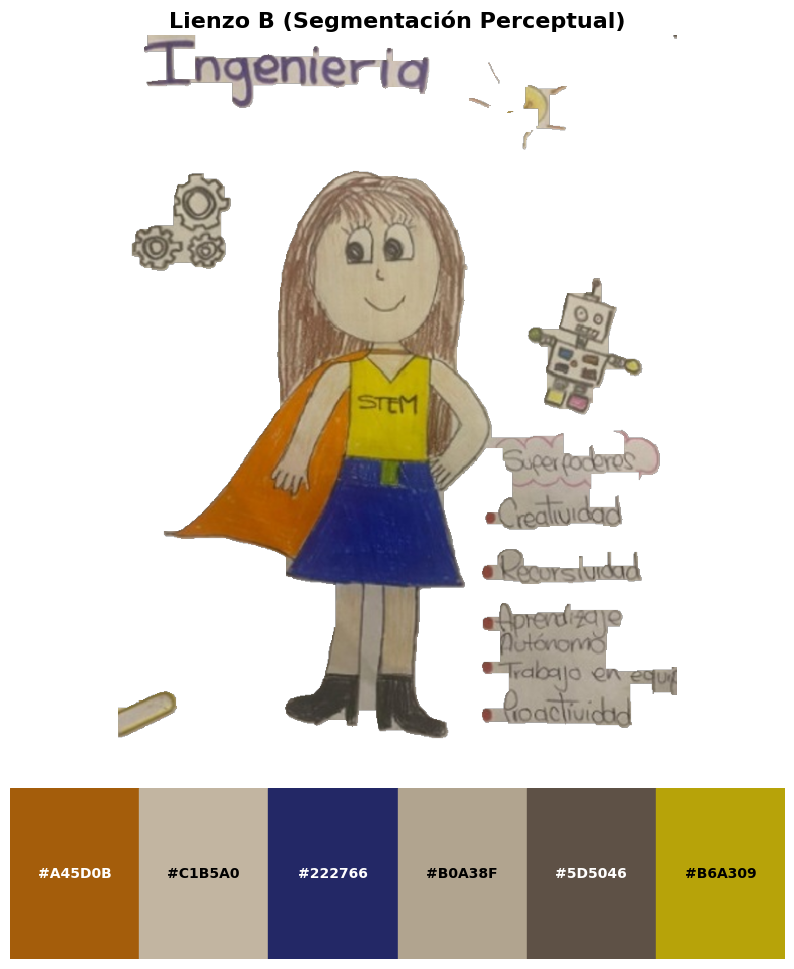

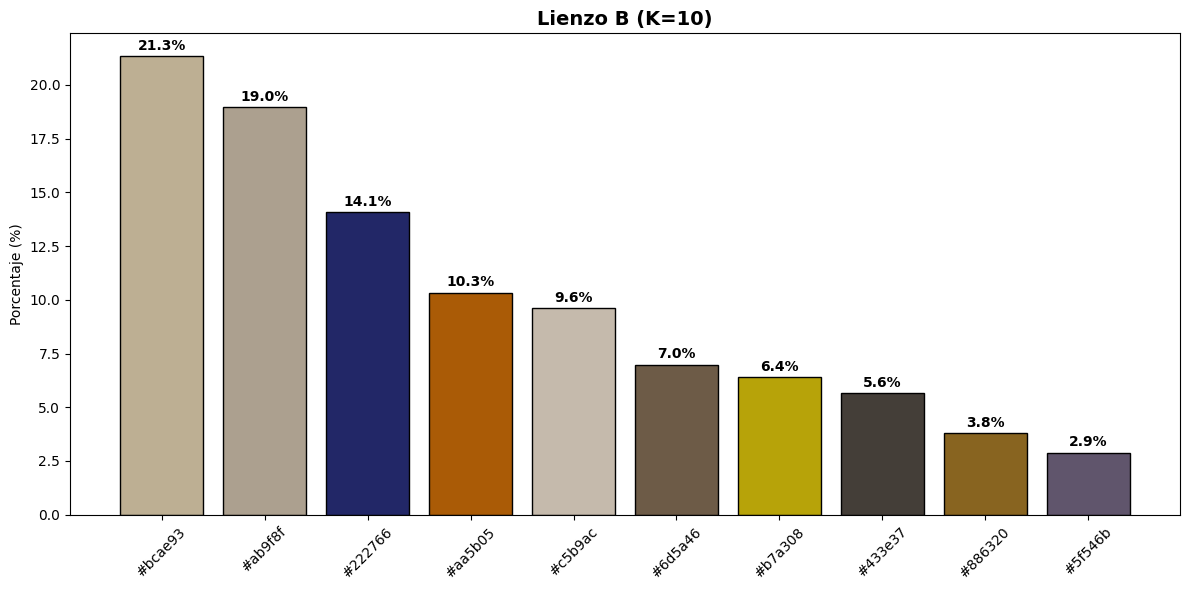


           REPORTE DE AUDITORÍA PERCEPTUAL


,Etapa,Métrica,Valor,Timestamp
0,Carga,Resolución,645x850 px,14:09:35
1,Segmentación,Píxeles Útiles,190800,14:09:36
2,Análisis Paleta 6,Inercia,61015559,14:09:38
3,Análisis Barras 10,Inercia,31318694,14:09:41


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import ndimage
from sklearn.cluster import KMeans
from collections import Counter
import time
from skimage import color

# --- 1. CONFIGURACIÓN Y REPOSITORIO DE AUDITORÍA ---
class Config:
    PATH_INPUT = "/content/Heroina 2.png"
    IGNORE_HEX = "#8E7D69"
    COLOR_TOLERANCE = 45
    # Mantenemos el parámetro por si deseas usarlo en otros experimentos,
    # pero para el Resultado 1 y 2 usaremos 0 para forzar K exacto.
    DELTA_E_THRESHOLD = 15.0
    N_CLUSTERS_PALETTE = 6
    N_CLUSTERS_BARS = 10
    RANDOM_SEED = 42
    audit_data = []

def record_audit(step, metric, value):
    Config.audit_data.append({
        "Etapa": step,
        "Métrica": metric,
        "Valor": value,
        "Timestamp": time.strftime("%H:%M:%S")
    })

# --- 2. NÚCLEO DE PROCESAMIENTO ---

def get_base_data(config):
    img_bgr = cv2.imread(config.PATH_INPUT)
    if img_bgr is None: raise FileNotFoundError(f"No se encontró la imagen")

    h, w, _ = img_bgr.shape
    record_audit("Carga", "Resolución", f"{w}x{h} px")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Segmentación por bordes
    edges = cv2.Canny(gray, 100, 200)
    mask = ndimage.binary_fill_holes(cv2.morphologyEx(edges, cv2.MORPH_CLOSE, np.ones((20,20), np.uint8)))

    rgba = np.zeros((h, w, 4), dtype=np.uint8)
    rgba[mask, :3], rgba[mask, 3] = img_rgb[mask], 255

    pixels_rgb = rgba[mask][:, :3]
    ignore_rgb = np.array([int(config.IGNORE_HEX.lstrip('#')[i:i+2], 16) for i in (0, 2, 4)])
    dist = np.linalg.norm(pixels_rgb - ignore_rgb, axis=1)
    filtered_pixels = pixels_rgb[dist > config.COLOR_TOLERANCE]

    record_audit("Segmentación", "Píxeles Útiles", len(pixels_rgb))
    return rgba, filtered_pixels

def process_clusters_lab(pixels, n_clusters, delta_e_threshold=0, audit_label=None):
    """
    KMeans en RGB. Si delta_e_threshold > 0, fusiona colores similares en LAB.
    Si es 0, devuelve exactamente n_clusters.
    """
    clt = KMeans(n_clusters=n_clusters, n_init=10, random_state=Config.RANDOM_SEED).fit(pixels)
    if audit_label:
        record_audit(f"Análisis {audit_label}", "Inercia", f"{clt.inertia_:.0f}")

    centers_rgb = clt.cluster_centers_
    counts = Counter(clt.labels_)

    if delta_e_threshold == 0:
        # Retorna los K centros ordenados por su índice de cluster
        return centers_rgb, np.array([counts[i] for i in range(n_clusters)])

    # Conversión a LAB para fusión perceptual
    centers_lab = color.rgb2lab(centers_rgb.reshape(-1, 1, 3) / 255.0).reshape(-1, 3)
    merged_cols_rgb, merged_counts = [], []
    skip = set()

    for i in range(len(centers_lab)):
        if i in skip: continue
        curr_rgb, curr_lab, curr_count = centers_rgb[i], centers_lab[i], counts[i]
        for j in range(i + 1, len(centers_lab)):
            if j not in skip:
                dist_de = np.linalg.norm(curr_lab - centers_lab[j])
                if dist_de < delta_e_threshold:
                    curr_rgb = (curr_rgb * curr_count + centers_rgb[j] * counts[j]) / (curr_count + counts[j])
                    curr_count += counts[j]
                    skip.add(j)
        merged_cols_rgb.append(curr_rgb)
        merged_counts.append(curr_count)

    return np.array(merged_cols_rgb), np.array(merged_counts)

# --- 3. FUNCIONES DE RENDERIZADO ---

def render_results(rgba_img, pixels, config):
    # RESULTADO 1: Forzamos exactamente 6 colores
    cols_p, _ = process_clusters_lab(pixels, config.N_CLUSTERS_PALETTE, 0, "Paleta 6")

    fig = plt.figure(figsize=(10, 12))
    grid = plt.GridSpec(5, 1, hspace=0.1)

    ax_img = fig.add_subplot(grid[:4, 0])
    ax_img.imshow(rgba_img)
    ax_img.set_title("Lienzo B (Segmentación Perceptual)", fontsize=16, fontweight='bold')
    ax_img.axis('off')

    ax_pal = fig.add_subplot(grid[4, 0])
    for i, col in enumerate(cols_p):
        ax_pal.add_patch(plt.Rectangle((i, 0), 1, 1, color=col/255.0))
        hex_val = '#%02x%02x%02x' % tuple(col.astype(int))
        lum = color.rgb2lab(col.reshape(1,1,3)/255.0)[0,0,0]
        text_c = 'white' if lum < 50 else 'black'
        ax_pal.text(i+0.5, 0.5, hex_val.upper(), color=text_c, ha='center', va='center', fontweight='bold')

    ax_pal.set_xlim(0, config.N_CLUSTERS_PALETTE)
    ax_pal.set_ylim(0, 1); ax_pal.axis('off')
    #ax_pal.set_title(f"Paleta de {len(cols_p)} Colores (K=6)", fontsize=12)
    plt.show()

    # RESULTADO 2: Gráfico de Barras forzando exactamente 10 colores
    cols_b, counts_b = process_clusters_lab(pixels, config.N_CLUSTERS_BARS, 0, "Barras 10")
    idx = np.argsort(counts_b)[::-1]
    cols_b, counts_b = cols_b[idx], counts_b[idx]
    percentages = (counts_b / counts_b.sum()) * 100
    hex_labels = ['#%02x%02x%02x' % tuple(c.astype(int)) for c in cols_b]

    plt.figure(figsize=(12, 6))
    bars = plt.bar(hex_labels, percentages, color=cols_b/255.0, edgecolor='black')
    plt.title("Lienzo B (K=10)", fontsize=14, fontweight='bold')
    plt.ylabel("Porcentaje (%)")
    plt.xticks(rotation=45)

    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h:.1f}%', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

# --- 4. EJECUCIÓN ---

try:
    rgba, filtered_pixels = get_base_data(Config)
    render_results(rgba, filtered_pixels, Config)

    print("\n" + "="*60)
    print("           REPORTE DE AUDITORÍA PERCEPTUAL")
    print("="*60)
    display(pd.DataFrame(Config.audit_data))

except Exception as e:
    print(f"Error en el pipeline: {e}")